# 29 -- Paper figures

All numbers come from `paper_data.py` and are cached in `data/paper_cache/` (set `REBUILD = True`, or delete a cache file, to recompute one).
Conventions are listed in `paper_data.py`'s docstring: (A+B)/2 lattice spectra; wall_points=100 pair-spectrum scans at each run's exact
$\bar\lambda$; our BubbleMaster cutoff window; $\hat D^{3.6}$ damping; lattice-vs-surrogate comparisons through the lattice shell estimator;
$I_{\mathcal K}=\sum_n P_n\,\Delta k/k_n$ over shells with $kR_*\le100$. Figures go to `notebooks/plots/paper/`.

In [1]:
#%pip install -e ../.

In [6]:
import numpy as np, pickle, matplotlib.pyplot as plt
from matplotlib import rc, rcParams
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
import paper_data as P

rc('font', **{'family': 'serif', 'serif': ['Computer Modern']}); rcParams['text.usetex'] = True
OUT = P.ROOT / 'notebooks' / 'plots' / 'paper'; OUT.mkdir(parents=True, exist_ok=True)
REBUILD = False
YLAB = r'$[H_*R_*\Omega_{\rm vac}]^{-2}\,d\Omega_{\rm GW}/d\ln k$'
COL3 = ['#0072B2', '#D55E00', '#009E73']
LB_LABEL = {0.84: '0.84', 0.069: '0.069', P.LB845: '0.845'}

def ticks(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=11)

## Fig. 1 -- $N_b=2$ spectra at $t/R_*\simeq1.095$ (lattice snapshot nearest $t_m$; surrogate at that time)

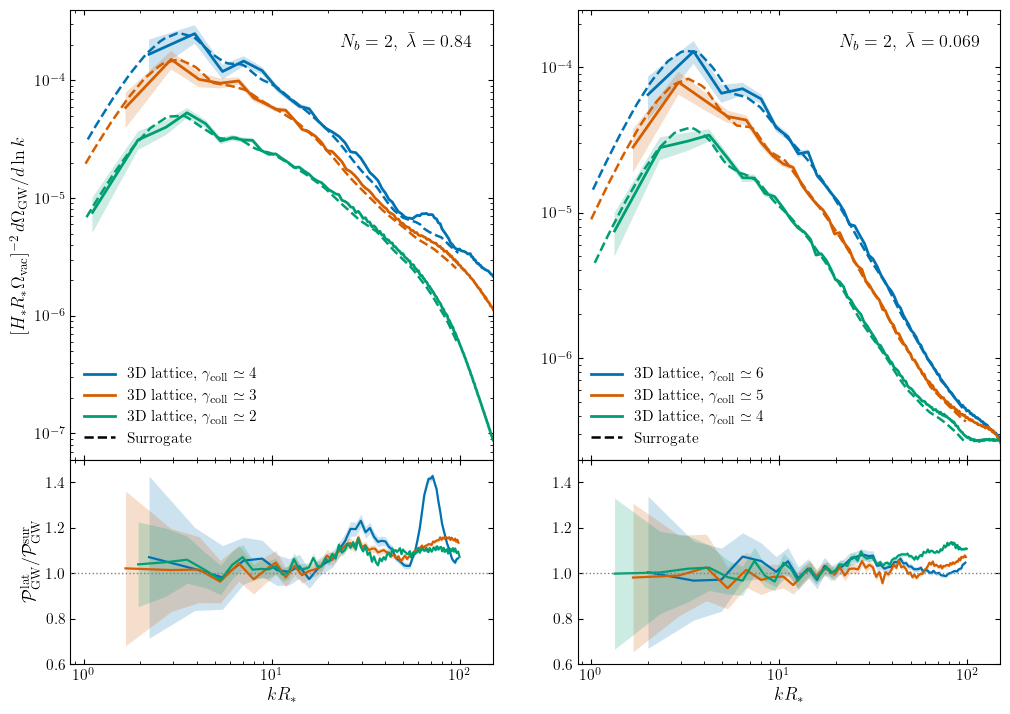

(0.84, (0, 1)) gamma=4.007: lattice snapshot t/R_*=1.086
(0.84, (0, 2)) gamma=3.006: lattice snapshot t/R_*=1.111
(0.84, (1, 2)) gamma=2.006: lattice snapshot t/R_*=1.086
(0.069, (0, 1)) gamma=6.001: lattice snapshot t/R_*=1.086
(0.069, (0, 2)) gamma=5.003: lattice snapshot t/R_*=1.102
(0.069, (1, 2)) gamma=4.001: lattice snapshot t/R_*=1.091


In [10]:
n2 = P.cached('fig12_n2', P.build_n2, REBUILD)
T_FIG1 = 1.095
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex='col', gridspec_kw=dict(height_ratios=[2.2, 1], hspace=0))
for col, lb in enumerate([0.84, 0.069]):
    a, b = axes[:, col]
    for (key, r), cc in zip([(k, v) for k, v in n2.items() if k[0] == lb], COL3):
        a.plot(r['kR_sh'], r['y_sh'], color=cc, lw=2, label=rf"3D lattice, $\gamma_{{\rm coll}}\simeq{round(r['gamma'])}$")
        a.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr'], 1e-300), r['y_sh'] + r['yerr'], color=cc, alpha=0.2, lw=0)
        m = (r['kR_rec'] >= 1) & (r['kR_rec'] <= 100); a.plot(r['kR_rec'][m], r['y_rec'][m], color=cc, lw=1.8, ls='--')
        x = r['kR_sh'][r['shell_mask']]; y = r['y_sh'][r['shell_mask']] / r['rec_shells']; e = r['yerr'][r['shell_mask']] / r['rec_shells']
        b.plot(x, y, color=cc, lw=1.6); b.fill_between(x, y - e, y + e, color=cc, alpha=0.2, lw=0)
    a.plot([], [], 'k--', lw=1.8, label='Surrogate')
    a.set_xscale('log'); a.set_yscale('log'); a.set_xlim(0.85, 150); a.set_ylim(*{0.84: (6e-8, 4e-4), 0.069: (2e-7, 2.5e-4)}[lb])
    a.legend(frameon=False, fontsize=11, loc='lower left'); a.text(0.95, 0.95, rf'$N_b=2,\ \bar\lambda={LB_LABEL[lb]}$', transform=a.transAxes, ha='right', va='top', fontsize=13)
    
    b.axhline(1, color='gray', ls=':', lw=1); b.set_ylim(0.6, 1.5); b.set_yticks([0.6, 0.8, 1.0, 1.2, 1.4]); b.set_xlabel(r'$kR_*$', fontsize=13)
    for ax in (a, b): ticks(ax)
axes[0, 0].set_ylabel(YLAB, fontsize=13); axes[1, 0].set_ylabel(r'$\mathcal{P}^{\rm lat}_{\rm GW}/\mathcal{P}^{\rm sur}_{\rm GW}$', fontsize=13)
fig.savefig(OUT / 'fig1_n2_spectra.pdf', bbox_inches='tight'); plt.show()
for k, r in n2.items(): print(k, f"gamma={r['gamma']:.3f}: lattice snapshot t/R_*={r['t_snap']/r['d']:.3f}")

## Fig. 2 -- $N_b=2$ integrated power $I_{\mathcal K}(t)$ up to the first periodic-image contact

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex='col', gridspec_kw=dict(height_ratios=[2.2, 1], hspace=0))
for col, lb in enumerate([0.84, 0.069]):
    a, b = axes[:, col]
    for (key, r), cc in zip([(k, v) for k, v in n2.items() if k[0] == lb], COL3):
        x = r['t'] / r['d']
        a.plot(x, r['I_lat'], color=cc, lw=2, label=rf"lattice, $\gamma_{{\rm coll}}\simeq{round(r['gamma'])}$"); a.plot(x, r['I_red'], color=cc, lw=2, ls='--')
        ok = (r['I_lat'] > 1e-3 * r['I_lat'].max()) & (r['I_red'] > 1e-3 * r['I_lat'].max()); b.plot(x[ok], (r['I_lat'] / r['I_red'])[ok], color=cc, lw=1.6)
    a.plot([], [], 'k--', lw=1.8, label='surrogate')
    for ax in (a, b): ax.axvline(T_FIG1, color='gray', ls=':', lw=1); ticks(ax)
    a.set_ylim(bottom=0); a.set_xlim(left=0); a.legend(frameon=False, fontsize=11, loc='upper left')
    a.text(0.95, 0.95, rf'$N_b=2,\ \bar\lambda={LB_LABEL[lb]}$', transform=a.transAxes, ha='right', va='top', fontsize=13)
    b.axhline(1, color='gray', ls=':', lw=1); b.set_ylim(0.8, 1.2); b.set_yticks([0.8, 0.9, 1.0, 1.1]); a.set_yticks(a.get_yticks()[1:]); b.set_xlabel(r'$t/R_*$', fontsize=13)
axes[0, 0].set_ylabel(r'$I_{\mathcal{K}}(t)$', fontsize=13); axes[1, 0].set_ylabel(r'$I^{\rm lat}_{\mathcal{K}}/I^{\rm sur}_{\mathcal{K}}$', fontsize=13)
fig.savefig(OUT / 'fig2_n2_integrated_power.pdf', bbox_inches='tight'); plt.show()

## Fig. 3 -- $N_b=3$ spectra (lattice snapshot nearest the latest pair $t_m$; damped surrogate at that time)

In [ ]:
n3 = P.cached('fig3_n3', P.build_n3, REBUILD)
C3 = '#CC79A7'
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex='col', gridspec_kw=dict(height_ratios=[2.2, 1], hspace=0))
for col, lb in enumerate([0.84, 0.069]):
    a, b = axes[:, col]; r = n3[lb]
    a.plot(r['kR_sh'], r['y_sh'], color=C3, lw=2, label='lattice')
    a.fill_between(r['kR_sh'], np.maximum(r['y_sh'] - r['yerr'], 1e-300), r['y_sh'] + r['yerr'], color=C3, alpha=0.2, lw=0)
    m = (r['kR_rec'] >= 1) & (r['kR_rec'] <= 100); a.plot(r['kR_rec'][m], r['y_rec'][m], color=C3, lw=1.8, ls='--', label='surrogate')
    x = r['kR_sh'][r['shell_mask']]; y = r['y_sh'][r['shell_mask']] / r['rec_shells']; e = r['yerr'][r['shell_mask']] / r['rec_shells']
    b.plot(x, y, color=C3, lw=1.6); b.fill_between(x, y - e, y + e, color=C3, alpha=0.2, lw=0)
    a.set_xscale('log'); a.set_yscale('log'); a.set_xlim(0.85, 150); a.set_ylim(*{0.84: (2e-7, 2e-3), 0.069: (3e-7, 1e-3)}[lb]); a.legend(frameon=False, fontsize=11, loc='lower left')
    a.text(0.95, 0.95, rf"$N_b=3,\ \bar\lambda={LB_LABEL[lb]},\ t/R_*={r['t_snap']/r['R']:.2f}$", transform=a.transAxes, ha='right', va='top', fontsize=13)
    b.axhline(1, color='gray', ls=':', lw=1); b.set_ylim(0.6, 1.45); b.set_yticks([0.6, 0.8, 1.0, 1.2]); b.set_xlabel(r'$kR_*$', fontsize=13)
    for ax in (a, b): ticks(ax)
axes[0, 0].set_ylabel(YLAB, fontsize=13); axes[1, 0].set_ylabel(r'$\mathcal{P}^{\rm lat}_{\rm GW}/\mathcal{P}^{\rm sur}_{\rm GW}$', fontsize=13)
fig.savefig(OUT / 'fig3_n3_spectra.pdf', bbox_inches='tight'); plt.show()

## Figs. 4 and 5 -- $N_b>3$: late-time spectra and integrated power, with ratios ($\gamma_*=4,5,6$; $\bar\lambda=0.845$ and $0.069$)

In [ ]:
nm = P.cached('fig45_nmany', P.build_nmany, REBUILD)
COLS = [4, 5, 6]; ROWS = [P.LB845, 0.069]
def grid():
    return plt.subplots(4, 3, figsize=(14, 12), sharex=True, sharey='row', gridspec_kw=dict(height_ratios=[2.2, 1, 2.2, 1], wspace=0, hspace=0))

fig, axes = grid()
for ir, lb in enumerate(ROWS):
    for c, gp in enumerate(COLS):
        a, b = axes[2 * ir, c], axes[2 * ir + 1, c]
        for r in [v for v in nm.values() if v['run']['lb'] == lb and v['run']['panel'] == gp]:
            cc = r['run']['col']
            a.fill_between(r['kR_sh'], r['y_lo'], r['y_hi'], color=cc, alpha=0.18, lw=0)
            a.plot(r['kR_sh'], r['y_med'], color=cc, lw=2, label=rf"lattice, $N_b={r['N_b']}$")
            m = (r['kR_rec'] >= 1) & (r['kR_rec'] <= 100); a.plot(r['kR_rec'][m], r['y_rec'][m], color=cc, lw=1.8, ls='--')
            x = r['kR_sh'][r['shell_mask']]; s = r['rec_shells']
            b.fill_between(x, r['y_lo'][r['shell_mask']] / s, r['y_hi'][r['shell_mask']] / s, color=cc, alpha=0.18, lw=0)
            b.plot(x, r['y_med'][r['shell_mask']] / s, color=cc, lw=1.6)
        a.plot([], [], 'k--', lw=1.8, label='surrogate')
        a.set_xscale('log'); a.set_yscale('log'); a.set_xlim(0.8, 160); a.set_ylim(3e-5, 2e-2); a.legend(frameon=False, fontsize=9, loc='lower left')
        a.text(0.95, 0.96, rf'$\gamma_*\simeq{gp}$,  $\bar\lambda={LB_LABEL[lb]}$', transform=a.transAxes, ha='right', va='top', fontsize=12)
        b.axhline(1, color='gray', ls=':', lw=1); b.set_ylim(0.4, 1.8)
        for ax in (a, b): ticks(ax)
for c in range(3): axes[3, c].set_xlabel(r'$kR_*$', fontsize=12)
for ir in range(2): axes[2 * ir, 0].set_ylabel(YLAB, fontsize=11); axes[2 * ir + 1, 0].set_ylabel(r'lat/sur', fontsize=11)
fig.savefig(OUT / 'fig4_nmany_spectra.pdf', bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharex=True, sharey='row', gridspec_kw=dict(height_ratios=[2.2, 1, 2.2, 1], wspace=0, hspace=0))
for ir, lb in enumerate(ROWS):
    for c, gp in enumerate(COLS):
        a, b = axes[2 * ir, c], axes[2 * ir + 1, c]
        for r in [v for v in nm.values() if v['run']['lb'] == lb and v['run']['panel'] == gp]:
            cc = r['run']['col']; x = r['t'] / r['R']
            a.plot(x, r['I_lat'], color=cc, lw=2, label=rf"lattice, $N_b={r['N_b']}$"); a.plot(x, r['I_red'], color=cc, lw=1.8, ls='--')
            ok = (r['I_lat'] > 1e-3 * r['I_lat'].max()) & (r['I_red'] > 1e-3 * r['I_lat'].max()); b.plot(x[ok], (r['I_lat'] / r['I_red'])[ok], color=cc, lw=1.6)
        a.plot([], [], 'k--', lw=1.8, label='surrogate'); a.set_ylim(bottom=0); a.set_xlim(0, 8); a.legend(frameon=False, fontsize=9, loc='upper left')
        a.text(0.95, 0.96, rf'$\gamma_*\simeq{gp}$,  $\bar\lambda={LB_LABEL[lb]}$', transform=a.transAxes, ha='right', va='top', fontsize=12)
        b.axhline(1, color='gray', ls=':', lw=1); b.set_ylim(0, 2.5)
        for ax in (a, b): ticks(ax)
for c in range(3): axes[3, c].set_xlabel(r'$t/R_*$', fontsize=12)
for ir in range(2): axes[2 * ir, 0].set_ylabel(r'$I_{\mathcal{K}}(t)$', fontsize=11); axes[2 * ir + 1, 0].set_ylabel(r'lat/sur', fontsize=11)
fig.savefig(OUT / 'fig5_nmany_integrated_power.pdf', bbox_inches='tight'); plt.show()

## Fig. 6 -- predictions: $\gamma_*=20$, $N_b=512$ spectra; peak vs $\gamma_*$ ($N_b=128$); peak vs $N_b$ ($\gamma_*=20$). Solid: damped, dotted: undamped

In [ ]:
from ptbuilder.weight_scan_diagnostics import characteristic_scale, load_kinematics
gsf, nbf = P.load_families(); X = P.X_PLOT; LBS = [0.84, 0.069]; CL = {0.84: '#0072B2', 0.069: '#D55E00'}
R20 = {lb: characteristic_scale(load_kinematics(P.DATA / f'phi4_lambda_bar{lb:g}/instanton.h5'), 20.0)[1] for lb in LBS}
NBS = [4, 8, 16, 32, 64, 128, 256, 512]; GS = list(range(2, 21))
def chw(dE, R, lb, L): return P.to_chw(dE, R, lb, L**3)
fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(16, 4.8))
for lb in LBS:
    L = nbf[(lb, 512, 0)][0]
    for which, ls in (('damped', '-'), ('undamped', ':')):
        y = chw(np.median([nbf[(lb, 512, rz)][1][which] for rz in range(16)], axis=0), R20[lb], lb, L)
        a0.plot(X, y, color=CL[lb], ls=ls, lw=1.8, label=rf'$\bar\lambda={lb}$' if which == 'damped' else None)
        pk = [chw(np.median(gsf[(lb, s)][2][which], axis=0), gsf[(lb, s)][0], lb, gsf[(lb, s)][1]).max() for s in GS]
        a1.plot(GS, pk, 'o' + ls if which == 'damped' else ls, color=CL[lb], ms=4, lw=1.5, label=rf'$\bar\lambda={lb}$' if which == 'damped' else None)
        if which == 'damped':
            pr = np.array([[chw(e, gsf[(lb, s)][0], lb, gsf[(lb, s)][1]).max() for e in gsf[(lb, s)][2][which]] for s in GS])
            a1.fill_between(GS, pr.min(axis=1), pr.max(axis=1), color=CL[lb], alpha=0.15, lw=0)
        pk = [chw(np.median([nbf[(lb, nb, rz)][1][which] for rz in range(16)], axis=0), R20[lb], lb, nbf[(lb, nb, 0)][0]).max() for nb in NBS]
        a2.plot(NBS, pk, 'o' + ls if which == 'damped' else ls, color=CL[lb], ms=4, lw=1.5, label=rf'$\bar\lambda={lb}$' if which == 'damped' else None)
        if which == 'damped':
            pr = np.array([[chw(nbf[(lb, nb, rz)][1][which], R20[lb], lb, nbf[(lb, nb, rz)][0]).max() for rz in range(16)] for nb in NBS])
            a2.fill_between(NBS, pr.min(axis=1), pr.max(axis=1), color=CL[lb], alpha=0.15, lw=0)
a0.set_xscale('log'); a0.set_yscale('log'); a0.set_xlabel(r'$kR_*$', fontsize=12); a0.set_ylabel(YLAB, fontsize=12)
a0.text(0.95, 0.95, r'$\gamma_*=20,\ N_b=512$', transform=a0.transAxes, ha='right', va='top', fontsize=12)
a1.set_xlabel(r'$\gamma_*$', fontsize=12); a1.set_ylabel(r'peak ' + YLAB, fontsize=11); a1.text(0.95, 0.95, r'$N_b=128$', transform=a1.transAxes, ha='right', va='top', fontsize=12)
a2.set_xscale('log'); a2.set_xlabel(r'$N_b$', fontsize=12); a2.set_xticks(NBS); a2.set_xticklabels([str(n) for n in NBS]); a2.minorticks_off()
a2.text(0.95, 0.95, r'$\gamma_*=20$', transform=a2.transAxes, ha='right', va='top', fontsize=12)
for ax in (a0, a1, a2): ticks(ax); ax.legend(frameon=False, fontsize=10, loc='lower left' if ax is a0 else 'lower right')
fig.tight_layout(); fig.savefig(OUT / 'fig6_predictions.pdf', bbox_inches='tight'); plt.show()

## Fig. 7 -- weight-weighted distributions vs $\gamma_*$ ($N_b=128$, 16 realizations): pair $\gamma_{ij}/\gamma_*$ and last collision time $t_{\max}/R_*$
Raw and $\hat D^{3.6}$-damped weights. For damped weights $t_{\max}$ = last time the pair's weight is $\ge1\%$ of its maximum (damped weights never return exactly to zero).

In [ ]:
wh = P.cached('fig7_weight_hists', P.build_weight_hists, REBUILD)
GS = P.GAMMA_STARS; xe = np.arange(min(GS) - 0.5, max(GS) + 1.5)
for kind in ('raw', 'damp'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for ir, lb in enumerate([0.84, 0.069]):
        for ic, (q, ye, lab) in enumerate((('gamma', np.linspace(0, 3.5, 81), r'$\gamma_{ij}/\gamma_*$'), ('tmax', np.linspace(0, 1.7, 81), r'$t_{\max}/R_*$'))):
            H = np.zeros((len(ye) - 1, len(GS)))
            for ix, gs in enumerate(GS):
                d = wh[(lb, gs)]; v = d['gamma'] / gs if q == 'gamma' else d[f'tmax_{kind}']; W = d[f'W_{kind}']; ok = np.isfinite(v)
                H[:, ix], _ = np.histogram(v[ok], bins=ye, weights=W[ok]); H[:, ix] /= max(H[:, ix].sum(), 1e-300)
            ax = axes[ir, ic]; pcm = ax.pcolormesh(xe, ye, np.where(H > 0, H, np.nan), norm=LogNorm(1e-5, 0.3), cmap='Greys', shading='flat', rasterized=True)
            ax.set_ylabel(lab, fontsize=12); ax.text(0.03, 0.95, rf'$\bar\lambda={lb}$', transform=ax.transAxes, va='top', fontsize=11); ticks(ax)
            if ir == 1: ax.set_xlabel(r'$\gamma_*$', fontsize=12)
    fig.colorbar(pcm, ax=axes, label='fraction of integrated weight', fraction=0.04, pad=0.02)
    fig.savefig(OUT / f'fig7_weight_distributions_{kind}.pdf', bbox_inches='tight'); plt.show()

## Fig. 8 -- where the power comes from: $N_b=512$, $\gamma_*=20$ spectral density in $t/R_*$ and $\gamma_{ij}/\gamma_*$ (damped)

In [ ]:
dec = P.cached('fig8_decomposition', P.build_decomposition, REBUILD)
def bands(H, edges, levels=(0.383, 0.683, 0.954)):
    yc = 0.5 * (edges[:-1] + edges[1:]); mass = H * np.diff(edges)[:, None]; tot = mass.sum(axis=0); out = {}
    for lev in levels:
        lo, hi = np.full(H.shape[1], np.nan), np.full(H.shape[1], np.nan)
        for k in range(H.shape[1]):
            if tot[k] <= 0: continue
            cum = np.r_[0., np.cumsum(mass[:, k]) / tot[k]]; yy = np.r_[edges[0], yc]
            lo[k], hi[k] = np.interp(0.5 * (1 - lev), cum, yy), np.interp(1 - 0.5 * (1 - lev), cum, yy)
        out[lev] = (lo, hi)
    return out
BST = {0.383: dict(color='0.05', lw=1.4, ls='-'), 0.683: dict(color='0.4', lw=1.1, ls='-.'), 0.954: dict(color='0.4', lw=1.0, ls='--')}
BLB = {0.383: r'38\% range', 0.683: r'68\% range', 0.954: r'95\% range'}
kR = P.X_PLOT; ke = np.sqrt(kR[:-1] * kR[1:]); ke = np.r_[kR[0]**2 / ke[0], ke, kR[-1]**2 / ke[-1]]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for ir, lb in enumerate([0.84, 0.069]):
    d = dec[lb]; V = d['L']**3; n = d['n_real']
    te = d['t'] / d['R']; Ht = P.to_chw(d['h_t'] / n, d['R'], lb, V) / np.diff(te)[:, None]
    ge = d['edges_g'] / 20.0; Hg = P.to_chw(d['h_g'] / n, d['R'], lb, V) / np.diff(ge)[:, None]
    for ic, (H, e, lab, ylim) in enumerate(((Ht, te, r'$t/R_*$', (0, 1.5)), (Hg, ge, r'$\gamma_{ij}/\gamma_*$', None))):
        ax = axes[ir, ic]; vmax = H.max()
        pcm = ax.pcolormesh(ke, e, np.maximum(H, vmax * 1e-7), norm=LogNorm(vmax * 1e-4, vmax), cmap='Blues', shading='auto', rasterized=True)
        for lev, (lo, hi) in bands(H, e).items(): ax.plot(kR, lo, label=BLB[lev], **BST[lev]); ax.plot(kR, hi, **BST[lev])
        ax.set_xscale('log'); ax.set_ylabel(lab, fontsize=12)
        if ylim: ax.set_ylim(*ylim)
        ax.text(0.03, 0.95, rf'$\bar\lambda={lb}$', transform=ax.transAxes, va='top', fontsize=11); ticks(ax)
        if ir == 1: ax.set_xlabel(r'$kR_*$', fontsize=12)
        fig.colorbar(pcm, ax=ax, fraction=0.05, pad=0.02)
axes[0, 0].legend(frameon=False, fontsize=8.5, loc='upper right')
fig.tight_layout(); fig.savefig(OUT / 'fig8_power_origin.pdf', bbox_inches='tight', dpi=250); plt.show()